# When does synthetic data help?

It is tempting to treat synthetic data as a free accuracy boost — generate more series, get a better model. A rigorous benchmark says otherwise, and being clear about it is the point of this page: synthetic data earns its place through **coverage, robustness, privacy, and pretraining breadth**, not by reliably lowering error on a well-configured model.

::: {.callout-important}
## The headline

On M4 Monthly, augmenting a properly-tuned global forecaster with `SynAugment` did **not** reliably beat training on the observed data alone — across panel sizes from 3 to 30 series and 20 random seeds, the win rate hovered around a coin flip and no result was statistically significant. Expect augmentation to be *neutral* for accuracy in this setting, and reach for synthetic data for the reasons in the second half of this page.
:::

## The benchmark

We sample panels of `n` M4 Monthly series and compare a global gradient-boosted forecaster (`HistGradientBoostingRegressor` via MLForecast, with per-series standardization — the correct configuration for M4's varied scales) trained on:

- **observed** — the real series only;
- **augmented** — real series plus `SynAugment` counterparts, fit on the training split only (leakage-safe).

We forecast the official 18-month M4 holdout and score seasonal MASE, paired within each seed. The full sweep (20 seeds) lives in [`benchmarks/benchmark_augmentation.py`](https://github.com/Nixtla/synforecast/blob/main/benchmarks/benchmark_augmentation.py); here we load its committed summary.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

summary_path = Path("benchmarks/data/augmentation_summary.json")
if not summary_path.exists():
    summary_path = Path("../../benchmarks/data/augmentation_summary.json")
summary = json.loads(summary_path.read_text())

table = pd.DataFrame(
    {
        "series in panel": e["n_series"],
        "observed MASE": round(e["observed_mase"], 3),
        "augmented MASE": round(e["augmented_mase"], 3),
        "improvement %": round(e["mean_dmase_pct"], 1),
        "win rate": f"{e['win_rate']:.0%}",
        "Wilcoxon p": round(e["wilcoxon_p"], 3),
    }
    for e in summary["by_size"]
)
print(f"{summary['dataset']} | {summary['model']} | {summary['seeds']} seeds")
table

M4 Monthly (official 18-month holdout) | HistGradientBoostingRegressor via MLForecast, per-series scaling | 20 seeds


,series in panel,observed MASE,augmented MASE,improvement %,win rate,Wilcoxon p
0,3,1.444,1.341,2.8,65%,0.231
1,5,1.336,1.433,-4.6,55%,0.985
2,10,1.467,1.436,0.4,40%,0.729
3,30,1.301,1.318,-2.0,35%,0.452


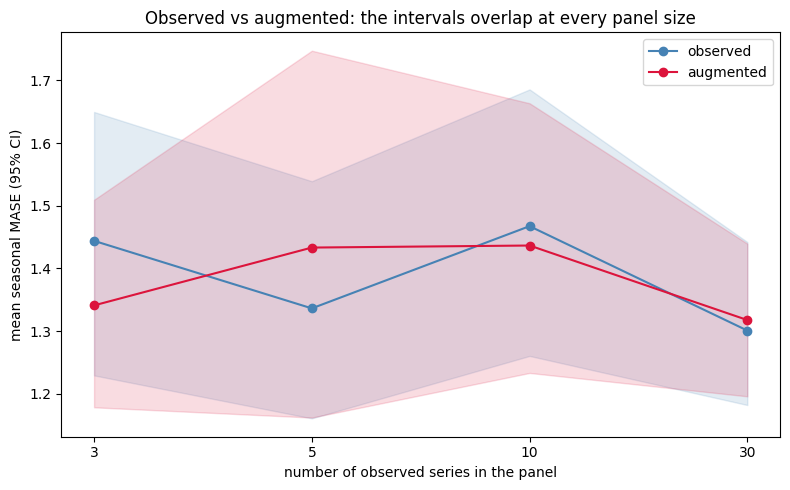

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = [e["n_series"] for e in summary["by_size"]]
xs = range(len(sizes))
for cond, color in [("observed", "steelblue"), ("augmented", "crimson")]:
    means = [e[f"{cond}_mase"] for e in summary["by_size"]]
    los = [e[f"{cond}_ci"][0] for e in summary["by_size"]]
    his = [e[f"{cond}_ci"][1] for e in summary["by_size"]]
    ax.plot(list(xs), means, marker="o", color=color, label=cond)
    ax.fill_between(list(xs), los, his, color=color, alpha=0.15)
ax.set_xticks(list(xs))
ax.set_xticklabels([str(n) for n in sizes])
ax.set(xlabel="number of observed series in the panel",
       ylabel="mean seasonal MASE (95% CI)",
       title="Observed vs augmented: the intervals overlap at every panel size")
ax.legend()
plt.tight_layout()
plt.show()

The confidence intervals overlap everywhere and the paired win rate never departs meaningfully from 50%. Two honest caveats about what this is *not*:

::: {.callout-warning}
## Read the result carefully

- **This is not evidence that synthetic data is useless** — it is evidence that *augmenting a model that already has enough signal* does not lower error. A gradient-boosted global model with a few full M4 histories is not starved for data.
- **A "win" is easy to fake.** An earlier draft of this benchmark showed a large apparent gain — until we noticed it came from an *unscaled* baseline (augmentation was compensating for the model's poor scale handling) and from too few seeds. With per-series scaling and 20 seeds, the effect vanished. Beware augmentation benchmarks that omit either.
:::

## Where synthetic data does earn its place

The value of synthetic data shows up away from the single-panel accuracy number:

::: {.callout-tip}
## Four honest use cases

- **Coverage and diversity.** [`generate_series`](../getting-started/quickstart) and the [balanced pool](balanced_pool) span behaviors — volatility clustering, long memory, intermittency, chaos — that no single real dataset contains. Useful for stress-testing a pipeline and for pretraining breadth.
- **Robustness testing.** Inject [anomalies](anomalies), [changepoints](changepoints), and [missingness](missingness) with known ground truth to measure how a model degrades.
- **Privacy.** Share a reproducible, statistically-similar panel without exposing proprietary series.
- **Pretraining at scale.** The diversity-targeted generators — [TSI](../generators/pretraining/tsi), [TCM](../generators/pretraining/tcm), and [KernelSynth](../generators/pretraining/kernel_synth) — exist to pretrain foundation models, where synthetic pretraining's payoff is established. That regime is far larger than this CPU benchmark.
:::

The coverage point is easy to see directly — one call yields a panel of visibly different data-generating processes:

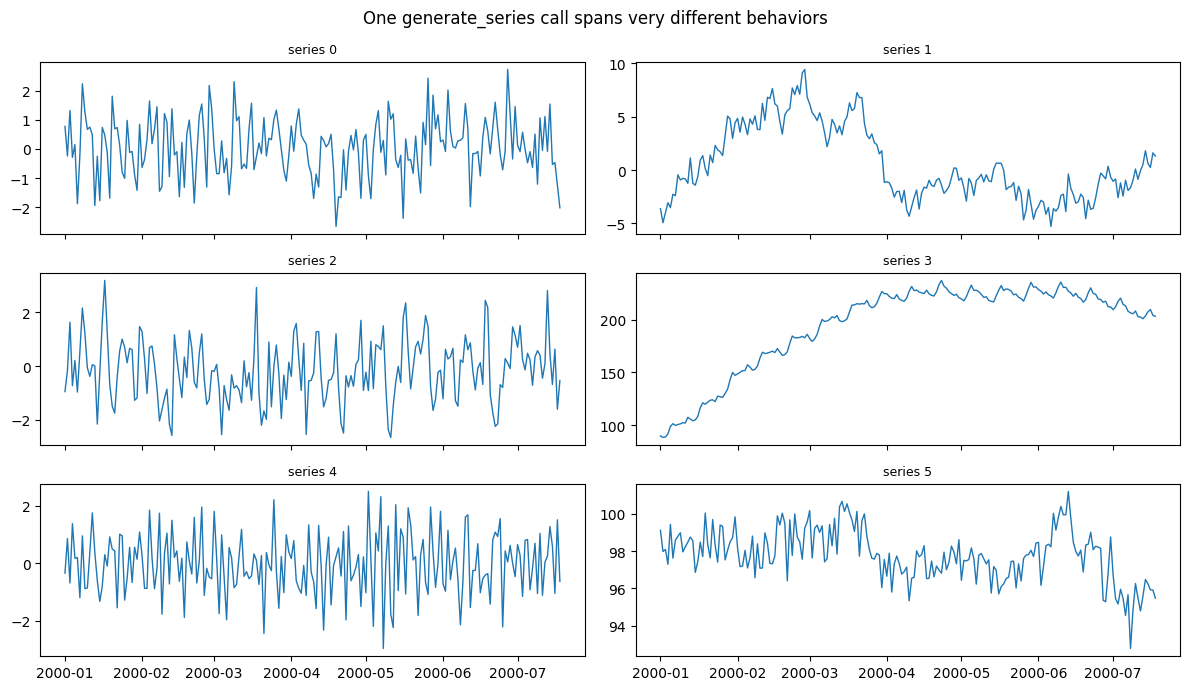

In [ ]:
from synforecast import generate_series

pool = generate_series(
    n_series=6, freq="D", min_length=200, max_length=200, engine="polars", seed=7
)
import polars as pl

fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for ax, uid in zip(axes.flat, pool["unique_id"].unique(maintain_order=True).to_list()):
    s = pool.filter(pl.col("unique_id") == uid)
    ax.plot(s["ds"], s["y"], linewidth=1)
    ax.set_title(f"series {uid}", fontsize=9)
fig.suptitle("One generate_series call spans very different behaviors")
plt.tight_layout()
plt.show()

## Reproduce

```bash
uv run python benchmarks/benchmark_augmentation.py --seeds 20 \
    --save benchmarks/data/augmentation_results.csv \
    --save-summary benchmarks/data/augmentation_summary.json
```

Use `--quick` for a fast smoke run. The script is model- and dataset-agnostic enough to re-point at your own panel — and the honest way to decide whether augmentation helps *your* problem is to run this paired, multi-seed comparison on *your* data, never on the final holdout.